In [1]:
# !pip install \
#   arviz \
#   "altair>=5" \
#   immutabledict \
#   joblib \
#   "natsort>=7.1.1,<8" \
#   "numpy>=2.0.2,<3" \
#   "pandas>=2.2.2,<3" \
#   "scipy>=1.13.1,<2" \
#   "tensorflow>=2.18,<2.19" \
#   "tensorflow-probability>=0.25,<0.26" \
#   "tf-keras>=2.18,<2.19" \
#   xarray


In [2]:
# %restart_python


In [3]:

%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import arviz as az
import IPython
import altair as alt
from IPython.display import HTML
import gc
import matplotlib.pyplot as plt

from meridian.mpa.mpa_utils_meridian import MeridianMPAInput

from meridian import constants
from meridian.data import load
from meridian.data import test_utils
from meridian.model import model
from meridian.model import spec
from meridian.model import prior_distribution
from meridian.analysis import optimizer
from meridian.analysis import analyzer
from meridian.analysis import visualizer
from meridian.analysis import summarizer
from meridian.analysis import formatter

# check if GPU is available
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print("Num CPUs Available: ", len(tf.config.experimental.list_physical_devices('CPU')))

Your runtime has 25.8 gigabytes of available RAM

Num GPUs Available:  0
Num CPUs Available:  1


In [5]:
home_dir = '/Users/mariappan.subramanian/Library/CloudStorage/OneDrive-TheTradeDesk/MMM/Media Parameter Analysis/tmp'

In [6]:
from client_config import client_config, ec50_multiplier_config, media_parameters_config

In [7]:
main_config =  {
    # "file_path": f"{home_dir}/data/MDF_BY_GEO_Jul8_Channel_events_wit_population.csv",
    "file_path": f"{home_dir}/data/MDF_BY_GEO_EXPANDED_CLIENTS_Aug11.csv",

    # "holiday_file_path": f"{home_dir}/data/holidays_updated_apr21/holiday_effect_",

    "paid_media_imp": ["TV_I", "Display_I", "Video_I"],  # Actual CPM will be calculated based on this
    "paid_media_spends": ["TV_AC", "Display_AC", "Video_AC"],

    "paid_media_viewability_imp": ["TV_VCR", "Display_VCR", "Video_VCR"],  # viewability rate will be calculated based on this
    "paid_media_cols": ["TV_I", "Display_I", "Video_I"],  # not used

    "reach_variables": ["TV_RHH", "Display_RPP", "Video_RPP"],
    "frequency_variables": ["TV_FHH", "Display_FPP", "Video_FPP"],

    "spend_variables_for_cpm_calc": ["TV_AC", "Display_AC", "Video_AC"],  # Prior CPM will be calculated based on this
    "imp_variables_for_cpm_calc": ['TV_I', 'Display_I', 'Video_I'],  # Prior CPM will be calculated based on this

    "response_kpi": "conversions",
    "prior_config": {},
    "prior_type": "spend"
}

Working Spend Plus Informative Transformation Priors

In [8]:
# get prior type for the coefficients (estimates)
prior_type = 'cpm_weighted_by_working_spend'  # "cpm_weighted_by_working_spend"
is_national = False
trans_prior_type = 'informative'
tag = "0_test"

print(f"{prior_type=}")
print(f"{is_national=}")
print(f"{trans_prior_type=}")
print(f"{tag=}")

prior_type='cpm_weighted_by_working_spend'
is_national=False
trans_prior_type='informative'
tag='0_test'


In [9]:
client = 'Mazda'

In [10]:
# ----------------------------- CREATE MODEL INPUT FILE FOR MERIDIAN --------------------------------- #
# create input object
main_config['prior_type'] = prior_type
mpa_input = MeridianMPAInput(client=client, client_config=client_config, main_config=main_config)
mdf_mw = mpa_input.mdf_mw.copy()

# write to a temp path for meridian
metrics = [mpa_input.target] + mpa_input.paid_media_imp + mpa_input.paid_media_spends
if is_national:
  # calculate pooled (geo, time level) standard deviation
  pooled_std =(mdf_mw['conversions']/mdf_mw['Population']).std()

  # national level standard deviation
  national_level_conversions = mdf_mw.groupby('WES')[['conversions']].sum().reset_index()['conversions']
  national_level_population = mdf_mw.groupby('WES')[['Population']].sum().reset_index()['Population']
  national_std = (national_level_conversions/national_level_population).std()

  correction_factor = np.round(pooled_std/national_std, 2)
  print(f"Correction factor: {correction_factor}")
  # aggregate out 'geo' field for national models
  mdf = mdf_mw. \
    groupby(['WES'])[metrics].sum(). \
      reset_index(). \
        assign(
          Region='National',
          Population=1.0,
          revenue_per_conversion=1.0
              )
else:
  correction_factor = 1.0
  mdf = mdf_mw[['WES'] + metrics + ['Region', 'Population']]. \
    reset_index(drop=True).assign(revenue_per_conversion= 1.0).copy()
  mdf.loc[:, 'WES'] = pd.to_datetime(mdf['WES']).dt.strftime('%Y-%m-%d')

# write to a temp path (input file path for meridian)
target_file_path = f"{home_dir}/trash/meridian/{client}_national_{is_national}_mdf.csv"
mdf.to_csv(target_file_path, index=False)

# ----------------------------- InputDataLoader --------------------------------- #
coord_to_columns = load.CoordToColumns(
  time='WES',
  geo='Region',
  population='Population',
  kpi='conversions',
  revenue_per_kpi='revenue_per_conversion',
  media=mpa_input.paid_media_imp,
  media_spend=mpa_input.paid_media_spends
)

ordered_chnl_names = [col.split("_")[0] for col in mpa_input.paid_media_imp]
print(f"ordered_chnl_names: {ordered_chnl_names}")
correct_media_to_channel = {col: col.split("_")[0] for col in mpa_input.paid_media_imp}
correct_media_spend_to_channel = {col: col.split("_")[0] for col in mpa_input.paid_media_spends}

# load and format input data
loader = load.CsvDataLoader(
  csv_path=target_file_path,
  kpi_type= 'non_revenue',
  coord_to_columns=coord_to_columns,
  media_to_channel=correct_media_to_channel,
  media_spend_to_channel=correct_media_spend_to_channel,
)
data = loader.load()


cost array: [69197739.76706284, 20208840.561141826, 32863319.60245556]
cpm array: [0.026279832630683553, 0.002973819213819918, 0.008836635744706934]
viewability percent [0.98683101 0.8001053  0.63033819]
working cost array: [0.6492919366289273, 0.15374247201480043, 0.19696559135627228]
prior type is cpm_weighted_by_working_spend and prior values are [2.65769447 0.07121162 0.27109391]
ordered_chnl_names: ['TV', 'Display', 'Video']


In [11]:
# ----------------------------- Define Prior Distribution --------------------------------- #
build_media_channel_args = data.get_paid_media_channels_argument_builder()

# a. beta_m prior (mean for the hierarchical distribution)
media_cf_prior = mpa_input.coeff_prior * correction_factor

if is_national:
  beta_m_prior_sigma = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, media_cf_prior)})
else:
  # hierarchical model
  allowable_deviation_percent = .1
  geometric_std = np.log(1 + allowable_deviation_percent)
  mu = np.log(0.8 * media_cf_prior) - (geometric_std ** 2 / 2)  # half-normal mean to log-normal mean
  geometric_std = np.full_like(mu, geometric_std)  # log-normal std-dev
  beta_m_prior_mu = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, mu)})
  beta_m_prior_sigma = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, geometric_std)})

# a. eta_m prior (std-dev for the hierarchical distribution)
eta_m_mu = 0.0
eta_m_mu_prior = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, np.repeat(eta_m_mu, len(ordered_chnl_names)))})

allowable_deviation_percent = .1
eta_m_sigma = np.log(1 + allowable_deviation_percent)
eta_m_sigma_prior = build_media_channel_args(**{chnl:val for chnl, val in zip(ordered_chnl_names, np.repeat(eta_m_sigma, len(ordered_chnl_names)))})

# b. Adstock Prior
adstock_lower_bounds = build_media_channel_args(**{chnl:media_parameters_config[chnl]['adstock_range'][0] for chnl in correct_media_to_channel.values()})
adstock_upper_bounds = build_media_channel_args(**{chnl:media_parameters_config[chnl]['adstock_range'][1] for chnl in correct_media_to_channel.values()})

# c. Half saturation Prior
ec50_mu_array = build_media_channel_args(**{chnl:np.round(ec50_multiplier_config[client][chnl], 2) for chnl in correct_media_to_channel.values()})
ec50_scale_array = np.array(ec50_mu_array) * 0.1  # roughly ±90% deviation within 3 standard deviations

# d. Slope Prior
slope_lb = build_media_channel_args(**{chnl:media_parameters_config[chnl]['slope_range'][0] for chnl in correct_media_to_channel.values()})
slope_ub = build_media_channel_args(**{chnl:media_parameters_config[chnl]['slope_range'][1] for chnl in correct_media_to_channel.values()})

# ----- define the prior distribution for the media parameters -----
eta_m=tfp.distributions.Normal(
  [float(x) for x in eta_m_mu_prior], [float(x) for x in eta_m_sigma_prior], name=constants.ETA_M)
alpha_m=tfp.distributions.Uniform([float(x) for x in adstock_lower_bounds], [float(x) for x in adstock_upper_bounds], name=constants.ALPHA_M)
ec_m=tfp.distributions.TruncatedNormal(
  loc=[float(x) for x in ec50_mu_array], scale=[float(x) for x in ec50_scale_array],
  low=[float(0.5) for _ in ec50_mu_array], high=[float(x) for x in ec50_mu_array],
  name=constants.EC_M)
slope_m=tfp.distributions.Uniform([float(x) for x in slope_lb], [float(x) for x in slope_ub], name=constants.SLOPE_M)

contribution_m=tfp.distributions.Beta(1.0, 99.0, name=constants.CONTRIBUTION_M)

if is_national:
  if trans_prior_type == 'informative':
    prior = prior_distribution.PriorDistribution(
        beta_m=tfp.distributions.HalfNormal([float(x) for x in beta_m_prior_sigma], name=constants.BETA_M),
        alpha_m=alpha_m,
        ec_m=ec_m,
        slope_m=slope_m
    )
  else:
    prior = prior_distribution.PriorDistribution(
        beta_m=tfp.distributions.HalfNormal([float(x) for x in beta_m_prior_sigma], name=constants.BETA_M))
else:
  if trans_prior_type == 'informative':
    prior = prior_distribution.PriorDistribution(
        # beta_m=tfp.distributions.Normal(
        #         loc=[float(x) for x in beta_m_prior_mu],
        #         scale=[float(x) for x in beta_m_prior_sigma], name=constants.BETA_M),
        contribution_m=contribution_m,
        # eta_m=eta_m,
        alpha_m=alpha_m,
        ec_m=ec_m,
        slope_m=slope_m
    )
  else:
    prior = prior_distribution.PriorDistribution(
        beta_m=tfp.distributions.Normal(
                loc=[float(x) for x in beta_m_prior_mu],
                scale=[float(x) for x in beta_m_prior_sigma], name=constants.BETA_M),
        eta_m=eta_m,
        alpha_m=alpha_m,
        ec_m=tfp.distributions.TruncatedNormal(loc=0.8, scale=0.8, low=0.5, high=10)
    )


In [12]:
# prior for beta_m
print(f'{ordered_chnl_names=}')
print(f"{beta_m_prior_mu=}")
print(f"{beta_m_prior_sigma=}")

# prior for adstock
print(f"{adstock_lower_bounds=}")
print(f"{adstock_upper_bounds=}")

# prior for half saturation
print(f"{ec50_mu_array=}")
print(f"{ec50_scale_array=}")

# prior for slope
print(f"{slope_lb=}")
print(f"{slope_ub=}")

ordered_chnl_names=['TV', 'Display', 'Video']
beta_m_prior_mu=[np.float64(0.7497734386532386), np.float64(-2.8697848268490014), np.float64(-1.5329755444602302)]
beta_m_prior_sigma=[np.float64(0.09531017980432493), np.float64(0.09531017980432493), np.float64(0.09531017980432493)]
adstock_lower_bounds=[0, 0, 0]
adstock_upper_bounds=[0.8, 0.45, 0.69]
ec50_mu_array=[np.float64(1.15), np.float64(5.65), np.float64(3.57)]
ec50_scale_array=array([0.115, 0.565, 0.357])
slope_lb=[1.0, 0.5, 1.0]
slope_ub=[2.0, 1.0, 2.0]


In [13]:

# ---------------------------------- Model Run ------------------------------------------- #
FILENAME = f"{tag}_{prior_type}_national_{is_national}_{client}.pkl"
FILEPATH = f"{home_dir}/results/1_MMM_Feasibility/model_objects/{FILENAME}"
# if not os.path.exists(FILEPATH):
model_spec = spec.ModelSpec(prior=prior, media_prior_type='coefficient', media_effects_dist='log_normal')
mmm = model.Meridian(input_data=data, model_spec=model_spec)
mmm.sample_prior(2000)
mmm.sample_posterior(n_chains=2, n_adapt=1000, n_burnin=1000, n_keep=2000)

# finally, save the model
print(f"Saving model to {FILEPATH}")
model.save_mmm(mmm, FILEPATH)

I0000 00:00:1759504353.601707 2065550 service.cc:148] XLA service 0x313919830 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759504353.602057 2065550 service.cc:156]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1759504353.654342 2065550 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/Users/mariappan.subramanian/Documents/repo/forked/meridian/meridian/model/prior_distribution.py:766: UserWarning: Changing the prior for `slope_m` may lead to convex Hill curves. This may lead to poor MCMC convergence and budget optimization may no longer produce a global optimum.
  warnings.warn(
2025-10-03 10:12:48.634634: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-03 10:12:48.917609: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:107] Warn

Saving model to /Users/mariappan.subramanian/Library/CloudStorage/OneDrive-TheTradeDesk/MMM/Media Parameter Analysis/tmp/results/1_MMM_Feasibility/model_objects/0_test_cpm_weighted_by_working_spend_national_False_Mazda.pkl


In [14]:
# media effects summary
media_effects_summary = visualizer.MediaSummary(mmm)
media_effects_summary_df = media_effects_summary.summary_table_without_ci(include_prior=False)
media_effects_summary_df

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, decay_function, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, decay_function, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


,channel,metric,distribution,impressions,pct_of_impressions,spend,pct_of_spend,cpm,incremental_outcome,pct_of_contribution,roi,effectiveness,mroi,cpik
0,TV,central_tendency,posterior,2.633114e+09,20.027205,69197736.0,56.594284,26.279810,8.857286e+08,46.996414,12.799962,0.336380,5.868146,0.078401
1,Display,central_tendency,posterior,6.795582e+09,51.686531,20208804.0,16.528038,2.973815,1.694571e+08,8.991331,8.385304,0.024936,5.590722,0.123712
2,Video,central_tendency,posterior,3.718988e+09,28.286261,32863300.0,26.877684,8.836623,1.344746e+08,7.135181,4.091941,0.036159,6.335331,0.247490
3,All Channels,central_tendency,posterior,1.314768e+10,100.000000,122269840.0,100.000000,9.299725,1.189659e+09,63.122997,9.729792,NaN,NaN,0.103124


In [15]:
time_coords = mmm.input_data.time
period_1 = slice('2024-01-06', '2024-06-29')
period_2 = slice('2024-01-04', '2025-06-28')

# get the media effects for the two periods
meffects_period_full = visualizer.MediaSummary(mmm).summary_table_without_ci(include_prior=False)
meffects_period_latest52wks = visualizer.MediaSummary(mmm, selected_times=time_coords[-52:].values.tolist()).summary_table_without_ci(include_prior=False)
meffects_period_1 = visualizer.MediaSummary(mmm, selected_times=time_coords.sel(time=period_1).values.tolist()).summary_table_without_ci(include_prior=False)
meffects_period_2 = visualizer.MediaSummary(mmm, selected_times=time_coords.sel(time=period_2).values.tolist()).summary_table_without_ci(include_prior=False)

# add total kpi for the two periods
meffects_period_full['conversions'] = mmm.input_data.kpi.sum().item()
meffects_period_latest52wks['conversions'] = mmm.input_data.kpi.sel(time=time_coords[-52:]).sum().item()
meffects_period_1['conversions'] = mmm.input_data.kpi.sel(time=period_1).sum().item()
meffects_period_2['conversions'] = mmm.input_data.kpi.sel(time=period_2).sum().item()

meffects_period_full.insert(loc=0, column='period', value='full')
meffects_period_latest52wks.insert(loc=0, column='period', value='latest_52_weeks')
meffects_period_1.insert(loc=0, column='period', value='period_1')
meffects_period_2.insert(loc=0, column='period', value='period_2')

media_effects_all = pd.concat([meffects_period_full, meffects_period_latest52wks, meffects_period_1, meffects_period_2])
media_effects_all


,period,channel,metric,distribution,impressions,pct_of_impressions,spend,pct_of_spend,cpm,incremental_outcome,pct_of_contribution,roi,effectiveness,mroi,cpik,conversions
0,full,TV,central_tendency,posterior,2.633114e+09,20.027205,69197736.0,56.594284,26.279810,8.857286e+08,46.996414,12.799962,0.336380,5.868146,0.078401,1.884444e+09
1,full,Display,central_tendency,posterior,6.795582e+09,51.686531,20208804.0,16.528038,2.973815,1.694571e+08,8.991331,8.385304,0.024936,5.590722,0.123712,1.884444e+09
2,full,Video,central_tendency,posterior,3.718988e+09,28.286261,32863300.0,26.877684,8.836623,1.344746e+08,7.135181,4.091941,0.036159,6.335331,0.247490,1.884444e+09
3,full,All Channels,central_tendency,posterior,1.314768e+10,100.000000,122269840.0,100.000000,9.299725,1.189659e+09,63.122997,9.729792,NaN,NaN,0.103124,1.884444e+09
0,latest_52_weeks,TV,central_tendency,posterior,2.036195e+09,20.532650,52990696.0,57.606430,26.024372,6.647901e+08,52.447720,12.545435,0.326487,5.226316,0.079889,1.254156e+09
1,latest_52_weeks,Display,central_tendency,posterior,5.027423e+09,50.695686,14805212.0,16.094812,2.944891,1.208089e+08,9.531051,8.159889,0.024030,5.376500,0.126600,1.254156e+09
2,latest_52_weeks,Video,central_tendency,posterior,2.853247e+09,28.771666,24191570.0,26.298767,8.478611,1.095530e+08,8.643014,4.528565,0.038396,6.870228,0.223513,1.254156e+09
3,latest_52_weeks,All Channels,central_tendency,posterior,9.916865e+09,100.000000,91987472.0,100.000000,9.275863,8.951529e+08,70.621849,9.731246,NaN,NaN,0.102959,1.254156e+09
0,period_1,TV,central_tendency,posterior,5.969156e+08,18.475706,16207086.0,53.519676,27.151384,2.209375e+08,35.800148,13.632158,0.370132,7.966643,0.073860,6.302878e+08
1,period_1,Display,central_tendency,posterior,1.768159e+09,54.727982,5403634.5,17.844095,3.056079,4.864795e+07,7.882791,9.002856,0.027513,6.177621,0.116740,6.302878e+08


In [98]:
pd.concat([meffects_period_1, meffects_period_2])

,channel,metric,distribution,impressions,pct_of_impressions,spend,pct_of_spend,cpm,incremental_outcome,pct_of_contribution,roi,effectiveness,mroi,cpik,conversions,period
0,TV,central_tendency,posterior,1.269693e+09,21.892887,32354788.0,57.983322,25.482368,407790720.0,44.676323,12.603724,0.321173,6.061960,0.079642,925902106.0,period_1
1,Display,central_tendency,posterior,3.063148e+09,52.816814,9167822.0,16.429741,2.992942,85419496.0,9.358274,9.317293,0.027886,6.023911,0.114394,925902106.0,period_1
2,Video,central_tendency,posterior,1.466728e+09,25.290295,14277556.0,25.586943,9.734289,46005380.0,5.040212,3.222222,0.031366,5.341736,0.316639,925902106.0,period_1
3,All Channels,central_tendency,posterior,5.799569e+09,100.000000,55800164.0,100.000000,9.621432,539216192.0,59.074856,9.663344,NaN,NaN,0.104017,925902106.0,period_1
0,TV,central_tendency,posterior,1.363417e+09,18.554657,36842980.0,55.428177,27.022526,483106496.0,49.703667,13.112586,0.354335,5.732103,0.076470,958542042.0,period_2
1,Display,central_tendency,posterior,3.732439e+09,50.794514,11041026.0,16.610600,2.958127,95503576.0,9.825731,8.649881,0.025587,5.448996,0.121565,958542042.0,period_2
2,Video,central_tendency,posterior,2.252258e+09,30.650827,18585758.0,27.961222,8.252056,88355984.0,9.090354,4.753947,0.039230,7.109960,0.212457,958542042.0,period_2
3,All Channels,central_tendency,posterior,7.348114e+09,100.000000,66469768.0,100.000000,9.045827,666964480.0,68.619797,10.034122,NaN,NaN,0.100020,958542042.0,period_2


In [92]:
meffects_period_1

,channel,metric,distribution,impressions,pct_of_impressions,spend,pct_of_spend,cpm,incremental_outcome,pct_of_contribution,roi,effectiveness,mroi,cpik
0,TV,central_tendency,posterior,1.269693e+09,21.892887,32354788.0,57.983322,25.482368,407790720.0,44.676323,12.603724,0.321173,6.061960,0.079642
1,Display,central_tendency,posterior,3.063148e+09,52.816814,9167822.0,16.429741,2.992942,85419496.0,9.358274,9.317293,0.027886,6.023911,0.114394
2,Video,central_tendency,posterior,1.466728e+09,25.290295,14277556.0,25.586943,9.734289,46005380.0,5.040212,3.222222,0.031366,5.341736,0.316639
3,All Channels,central_tendency,posterior,5.799569e+09,100.000000,55800164.0,100.000000,9.621432,539216192.0,59.074856,9.663344,NaN,NaN,0.104017


In [91]:
meffects_period_2

,channel,metric,distribution,impressions,pct_of_impressions,spend,pct_of_spend,cpm,incremental_outcome,pct_of_contribution,roi,effectiveness,mroi,cpik
0,TV,central_tendency,posterior,1.363417e+09,18.554657,36842980.0,55.428177,27.022526,483106496.0,49.703667,13.112586,0.354335,5.732103,0.076470
1,Display,central_tendency,posterior,3.732439e+09,50.794514,11041026.0,16.610600,2.958127,95503576.0,9.825731,8.649881,0.025587,5.448996,0.121565
2,Video,central_tendency,posterior,2.252258e+09,30.650827,18585758.0,27.961222,8.252056,88355984.0,9.090354,4.753947,0.039230,7.109960,0.212457
3,All Channels,central_tendency,posterior,7.348114e+09,100.000000,66469768.0,100.000000,9.045827,666964480.0,68.619797,10.034122,NaN,NaN,0.100020


In [81]:
model_summary = az.summary(mmm.inference_data.posterior).reset_index()
media_model_summary = model_summary[~(model_summary['index'].str.startswith('mu') | model_summary['index'].str.startswith('knot') | model_summary['index'].str.startswith('tau_g'))]
media_parameters_model_summary = media_model_summary[~(model_summary['index'].str.startswith('beta_') | model_summary['index'].str.startswith('eta_'))]
media_parameters_model_summary

/Users/mariappan.subramanian/Documents/repo/forked/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/forked/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/var/folders/yc/q3l7zfz56nqcr4r6q26n67rm0000gp/T/ipykernel_21963/2442226161.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  media_parameters_model_summary = media_model_summary[~(model_summary['index'].str.startswith('beta_') | model_summary['index'].str.startswith('eta_'))]


,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,alpha_m[TV],0.785,0.014,0.759,0.800,0.000,0.000,2065.0,1056.0,1.0
1,alpha_m[Display],0.293,0.104,0.106,0.450,0.002,0.001,2501.0,2613.0,1.0
2,alpha_m[Video],0.686,0.004,0.679,0.690,0.000,0.000,3093.0,1398.0,1.0
114,ec_m[TV],0.925,0.103,0.744,1.117,0.004,0.002,842.0,1474.0,1.0
115,ec_m[Display],5.346,0.255,4.876,5.650,0.004,0.004,3434.0,2026.0,1.0
116,ec_m[Video],3.348,0.171,3.043,3.570,0.003,0.002,2575.0,1725.0,1.0
276,sigma,0.259,0.004,0.252,0.265,0.000,0.000,2894.0,2606.0,1.0
277,slope_m[TV],1.037,0.036,1.000,1.106,0.001,0.001,1872.0,1272.0,1.0
278,slope_m[Display],0.842,0.143,0.555,1.000,0.009,0.005,342.0,861.0,1.0
279,slope_m[Video],1.848,0.107,1.656,1.999,0.002,0.002,2491.0,1859.0,1.0


In [121]:
model_summary = az.summary(mmm.inference_data.posterior).reset_index()
media_model_summary = model_summary[~(model_summary['index'].str.startswith('mu') | model_summary['index'].str.startswith('knot') | model_summary['index'].str.startswith('tau_g'))]
media_parameters_model_summary = media_model_summary[~(model_summary['index'].str.startswith('beta_') | model_summary['index'].str.startswith('eta_'))]
media_parameters_model_summary

/Users/mariappan.subramanian/Documents/repo/forked/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/forked/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/mariappan.subramanian/Documents/repo/forked/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/forked/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/var/folders/yc/q3l7zfz56nqcr4

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,alpha_m[TV],0.774,0.027,0.724,0.800,0.000,0.001,3899.0,2161.0,1.00
1,alpha_m[Display],0.127,0.079,0.000,0.265,0.001,0.001,2693.0,1957.0,1.00
2,alpha_m[Video],0.454,0.065,0.328,0.569,0.001,0.001,3333.0,2457.0,1.00
96,ec_m[TV],4.104,0.627,2.955,5.240,0.012,0.010,2571.0,2116.0,1.00
97,ec_m[Display],1.779,0.380,1.138,2.510,0.010,0.006,1560.0,2379.0,1.01
98,ec_m[Video],3.241,0.474,2.385,4.147,0.008,0.007,3747.0,3249.0,1.00
258,sigma,0.405,0.006,0.393,0.417,0.000,0.000,4279.0,3230.0,1.00
259,slope_m[TV],1.000,0.000,1.000,1.000,0.000,NaN,4000.0,4000.0,NaN
260,slope_m[Display],1.000,0.000,1.000,1.000,0.000,NaN,4000.0,4000.0,NaN
261,slope_m[Video],1.000,0.000,1.000,1.000,0.000,NaN,4000.0,4000.0,NaN


In [122]:
media_model_summary[(model_summary['index'].str.startswith('beta_m') | model_summary['index'].str.startswith('eta_'))]

/var/folders/yc/q3l7zfz56nqcr4r6q26n67rm0000gp/T/ipykernel_10553/2069341842.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  media_model_summary[(model_summary['index'].str.startswith('beta_m') | model_summary['index'].str.startswith('eta_'))]


,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
93,beta_m[TV],0.168,0.087,0.005,0.334,0.001,0.001,3480.0,2727.0,1.00
94,beta_m[Display],-0.665,0.089,-0.827,-0.492,0.001,0.001,3958.0,2823.0,1.00
95,beta_m[Video],-1.455,0.091,-1.626,-1.286,0.001,0.001,4065.0,2856.0,1.00
99,eta_m[TV],0.023,0.270,-0.381,0.387,0.038,0.003,71.0,688.0,1.03
100,eta_m[Display],0.000,0.538,-0.614,0.612,0.379,0.001,3.0,63.0,1.83
101,eta_m[Video],-0.001,0.674,-0.759,0.744,0.475,0.001,3.0,60.0,1.83


In [86]:
np.exp(-0.633) * np.exp(-0.005)

np.float64(0.528348064179391)

In [123]:
tv_beta_gm = media_model_summary[(model_summary['index'].str.startswith('beta_gm') & model_summary['index'].str.contains('TV'))].reset_index(drop=True)
tv_beta_gm

/var/folders/yc/q3l7zfz56nqcr4r6q26n67rm0000gp/T/ipykernel_10553/3460160385.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  tv_beta_gm = media_model_summary[(model_summary['index'].str.startswith('beta_gm') & model_summary['index'].str.contains('TV'))].reset_index(drop=True)


,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,"beta_gm[ALABAMA, TV]",1.098,0.253,0.631,1.579,0.004,0.004,4867.0,3263.0,1.0
1,"beta_gm[ARIZONA, TV]",1.303,0.346,0.756,2.017,0.006,0.006,4173.0,3226.0,1.0
2,"beta_gm[CALIFORNIA, TV]",1.135,0.282,0.623,1.690,0.007,0.005,1838.0,2359.0,1.0
3,"beta_gm[COLORADO, TV]",1.022,0.258,0.521,1.492,0.003,0.005,6123.0,3062.0,1.0
4,"beta_gm[CONNECTICUT, TV]",0.953,0.230,0.508,1.365,0.003,0.004,5597.0,2774.0,1.0
5,"beta_gm[FLORIDA, TV]",1.435,0.442,0.757,2.318,0.008,0.010,3564.0,3203.0,1.0
6,"beta_gm[GEORGIA, TV]",1.097,0.260,0.632,1.591,0.003,0.005,5779.0,3309.0,1.0
7,"beta_gm[ILLINOIS, TV]",0.923,0.227,0.514,1.342,0.003,0.003,5544.0,3387.0,1.0
8,"beta_gm[INDIANA, TV]",1.291,0.336,0.680,1.934,0.006,0.006,3966.0,2576.0,1.0
9,"beta_gm[KENTUCKY, TV]",1.229,0.295,0.689,1.784,0.004,0.005,4434.0,2980.0,1.0


In [88]:
np.exp(beta_m_prior_mu)

array([1.70946006, 0.46771786, 0.21194596])

In [124]:
video_beta_gm = media_model_summary[(model_summary['index'].str.startswith('beta_gm') & model_summary['index'].str.contains('Video'))].reset_index(drop=True)
video_beta_gm

/var/folders/yc/q3l7zfz56nqcr4r6q26n67rm0000gp/T/ipykernel_10553/3747373502.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  video_beta_gm = media_model_summary[(model_summary['index'].str.startswith('beta_gm') & model_summary['index'].str.contains('Video'))].reset_index(drop=True)


,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,"beta_gm[ALABAMA, Video]",0.192,0.108,0.035,0.387,0.001,0.002,5817.0,2377.0,1.00
1,"beta_gm[ARIZONA, Video]",1.480,0.494,0.547,2.396,0.010,0.009,2181.0,1339.0,1.00
2,"beta_gm[CALIFORNIA, Video]",0.874,0.432,0.139,1.621,0.052,0.014,71.0,362.0,1.02
3,"beta_gm[COLORADO, Video]",0.202,0.110,0.039,0.396,0.002,0.002,5068.0,2810.0,1.00
4,"beta_gm[CONNECTICUT, Video]",0.273,0.176,0.034,0.596,0.003,0.004,5210.0,3211.0,1.00
5,"beta_gm[FLORIDA, Video]",0.241,0.154,0.031,0.535,0.002,0.004,4700.0,2843.0,1.00
6,"beta_gm[GEORGIA, Video]",3.021,0.565,2.002,4.112,0.009,0.008,3497.0,2903.0,1.00
7,"beta_gm[ILLINOIS, Video]",2.243,0.456,1.404,3.065,0.007,0.007,4066.0,2832.0,1.00
8,"beta_gm[INDIANA, Video]",0.228,0.133,0.034,0.472,0.002,0.003,4947.0,3178.0,1.00
9,"beta_gm[KENTUCKY, Video]",0.200,0.120,0.027,0.415,0.002,0.003,6112.0,2820.0,1.00


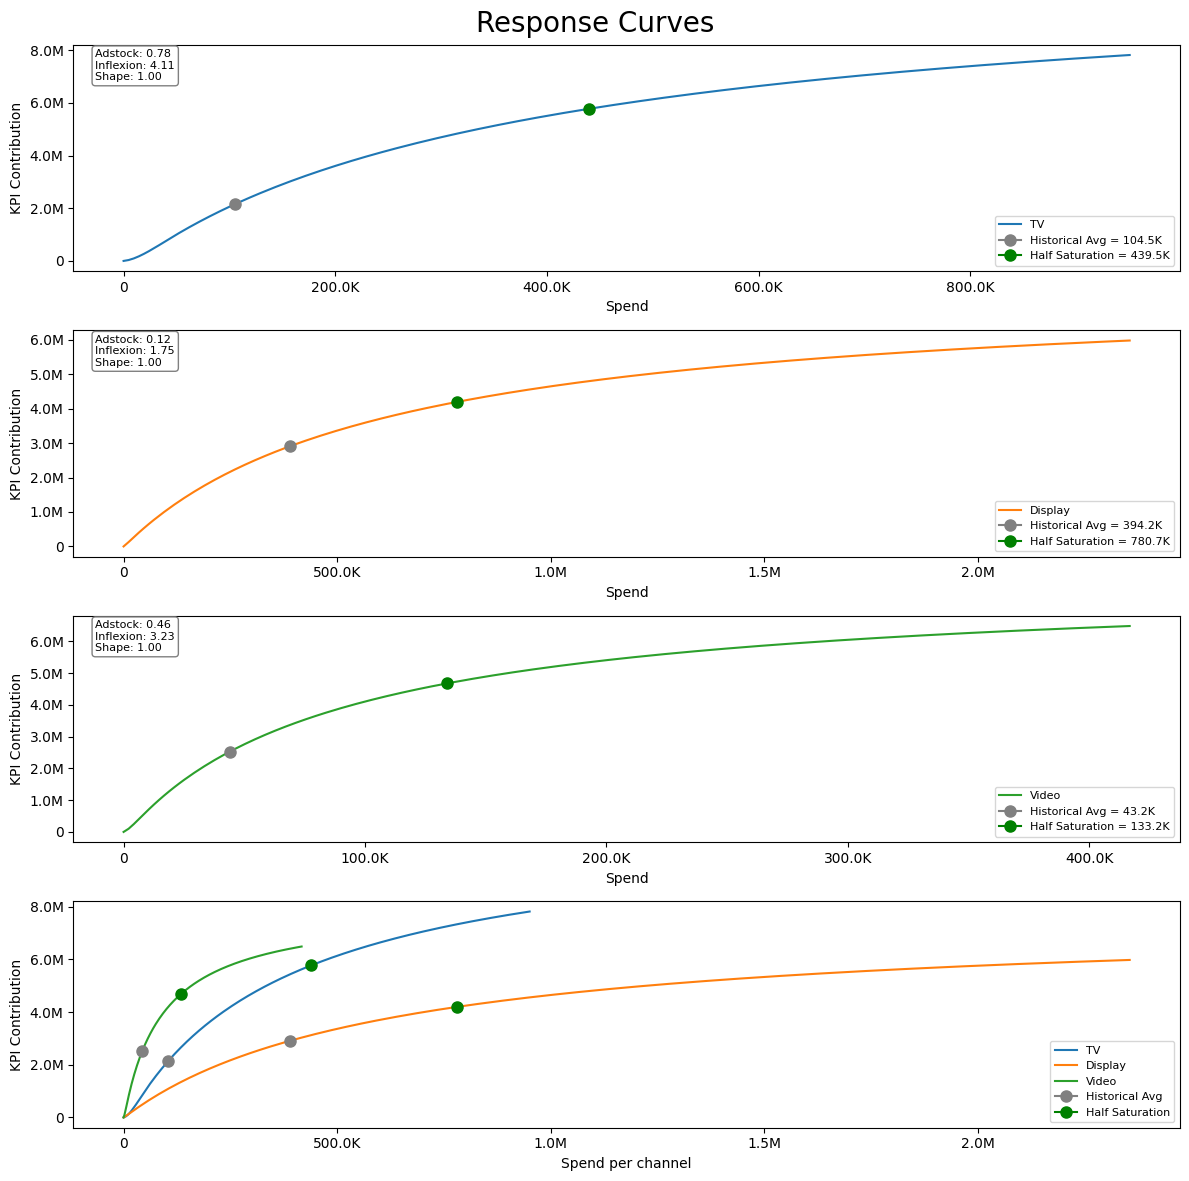

None

In [125]:
# RC Plots
from meridian.analysis.response_curve_generator import ResponseCurveGenerator
# Initialize simulator
simulator = ResponseCurveGenerator(mmm)

# Generate response curves
response_curves, metadata = simulator.generate_response_curves(
  max_multiplier=3.0,
  num_steps=200,
  aggregation_level="national"
)

# Create MPA-style visualization
rc = simulator.plot_response_curves(
  response_curves, metadata,
  figure_size=(12, 12),
  n_columns=1,
  marker_size=8,
  legend_fontsize=8
)
display(rc)

,media_channel,alpha,ec,slope
0,TV,0.762369,5.708371,2.932938
1,Display,0.105754,1.774496,0.969562
2,Video,0.622691,3.457225,1.967474


,media_channel,media_scaled_sum,adstocked_media_sum,saturated_media_sum
0,TV,2676.840820,2578.691406,34.757183
1,Display,2422.896973,2419.285156,804.260132
2,Video,2963.426514,2918.022461,315.025391


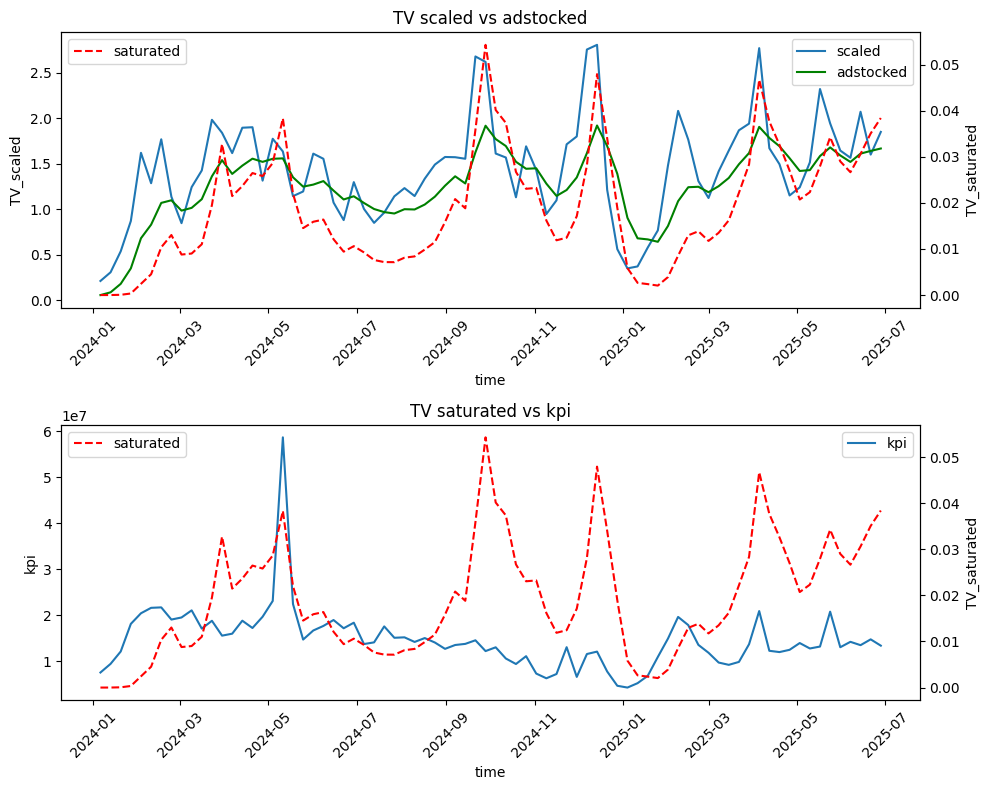

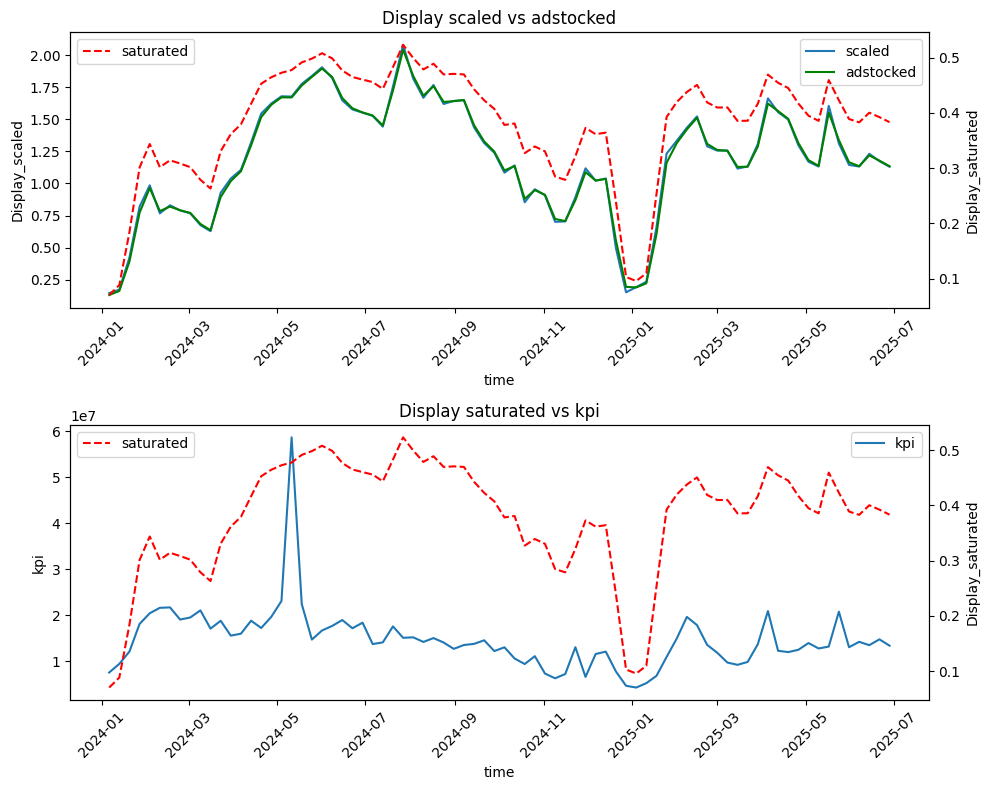

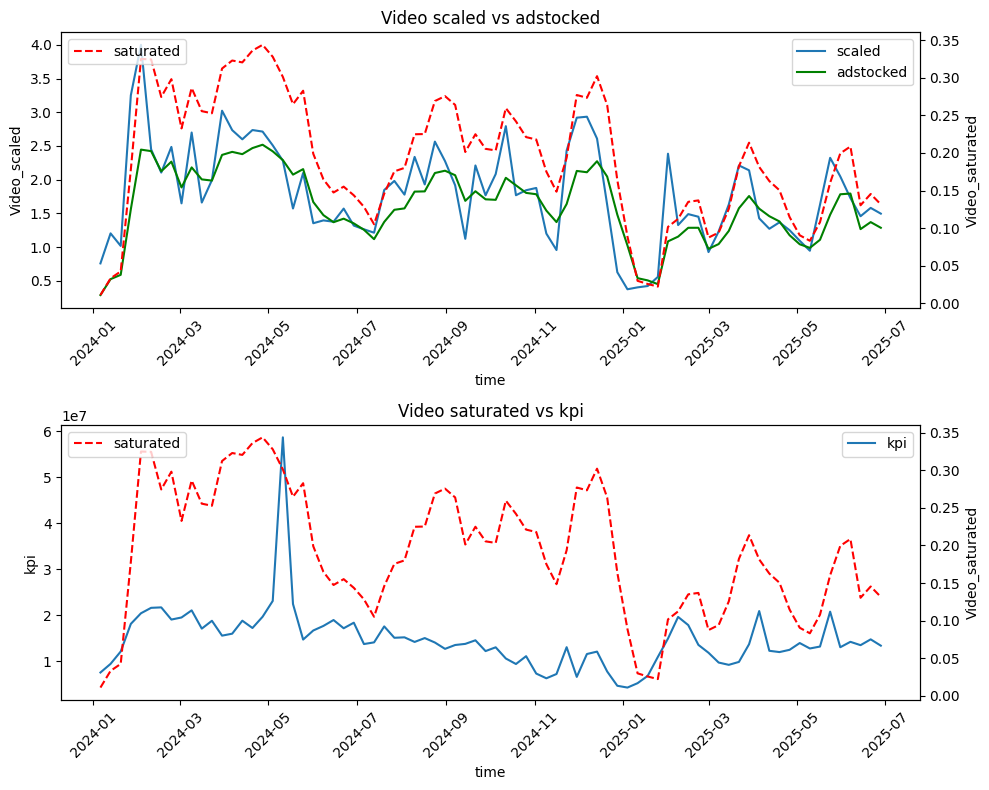

In [114]:
# Media Transformations Plots
from meridian.mpa.plot_media_transformations import ExportMediaTransformations
export_media_transformations = ExportMediaTransformations(mmm)
display(export_media_transformations.media_parameters_df)
display(export_media_transformations.media_sum_to_debug_df)
export_media_transformations.plot_media_journey_all()

In [1]:
# model_diagnostics = visualizer.ModelDiagnostics(mmm)
# display(model_diagnostics.plot_prior_and_posterior_distribution(parameter='alpha_m'))
# display(model_diagnostics.plot_prior_and_posterior_distribution(parameter='ec_m'))
# display(model_diagnostics.plot_prior_and_posterior_distribution(parameter='slope_m'))
# display(model_diagnostics.plot_prior_and_posterior_distribution(parameter='beta_m'))
# display(model_diagnostics.plot_prior_and_posterior_distribution(parameter='eta_m'))
# display(model_diagnostics.plot_prior_and_posterior_distribution(parameter='beta_gm'))


In [3]:
# model_diagnostics.plot_prior_and_posterior_distribution(parameter='contribution_m')